#  Notebook Overview: Drywall Joint & Seam Segmentation

This notebook applies the Advanced SAM-FiLM architecture to the task of identifying and segmenting drywall joints, tapes, and seams.

###  Execution Steps:
1. **System Setup:** Installs necessary CV and Deep Learning frameworks; downloads SAM Vit-B weights.
2. **Configuration:** Sets up drywall-specific prompts: *"segment taping area"*, *"segment joint/tape"*, *"segment drywall seam"*.
3. **Dataset Ingestion:** Loads `drywall_dataset_v2` and visualizes the split distribution (Train/Val/Test).
4. **Advanced Data Visualization:** Displays side-by-side samples of raw drywall footage and its corresponding ground truth annotations.
5. **Metric Suite Implementation:** Includes custom functions to compute **Foreground IoU**, **mIoU**, and **Foreground F1** for accurate drywall detection tracking.
6. **Advanced SAM-FiLM Net:** Defines the transformer-based encoder with FiLM modulation and Laplacian refinement heads.
7. **Training & Validation Loop:** Executes 20 epochs of training with interactive `tqdm` progress tracking and automated checkpoint saving (`best_drywall_model.pth`).
8. **Inference Profiling:** Benchmarks the model Complexity (Total Parameters and GFLOPs) and real-world Inference Latency (ms).
9. **Failure Case Analysis:** Automatically identifies and visualizes "Difficult" samples (IoU < 0.3) for model debugging.


In [2]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch: 2.5.1+cu121
CUDA available: True


In [18]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '4'

In [19]:
import os
import json
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [21]:
class Config:
    DATASET_DIR = r"drywall_dataset_v2"
    PROMPTS = ["segment taping area", "segment joint", "segment drywall seam"]
    IMAGE_SIZE = 640
    BATCH_SIZE = 4
    NUM_EPOCHS = 20
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-4
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()
print(f"Dataset: {cfg.DATASET_DIR}")
print(f"Device: {cfg.DEVICE}")
print(f"Prompts: {cfg.PROMPTS}")

Dataset: drywall_dataset_v2
Device: cuda
Prompts: ['segment taping area', 'segment joint', 'segment drywall seam']


In [22]:
class DrywallDataset(Dataset):
    def __init__(self, split, dataset_dir, prompts, image_size=640):
        self.split = split
        self.dataset_dir = dataset_dir
        self.prompts = prompts
        self.image_size = image_size
        
        with open(os.path.join(dataset_dir, "metadata.json"), "r") as f:
            self.metadata = json.load(f)
        
        self.samples = [m for m in self.metadata["images"] if m["split"] == split]
        print(f"{split}: {len(self.samples)} samples")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        img_path = os.path.join(self.dataset_dir, self.split, "images", sample["image_file"])
        mask_path = os.path.join(self.dataset_dir, self.split, "masks", sample["mask_file"])
        
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        
        image = image.resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)
        
        image = transforms.ToTensor()(image)
        mask = torch.from_numpy(np.array(mask)).float() / 255.0
        
        prompt = random.choice(self.prompts)
        
        return image, mask, prompt

train_ds = DrywallDataset("train", cfg.DATASET_DIR, cfg.PROMPTS, cfg.IMAGE_SIZE)
val_ds = DrywallDataset("val", cfg.DATASET_DIR, cfg.PROMPTS, cfg.IMAGE_SIZE)
test_ds = DrywallDataset("test", cfg.DATASET_DIR, cfg.PROMPTS, cfg.IMAGE_SIZE)

train: 715 samples
val: 153 samples
test: 154 samples


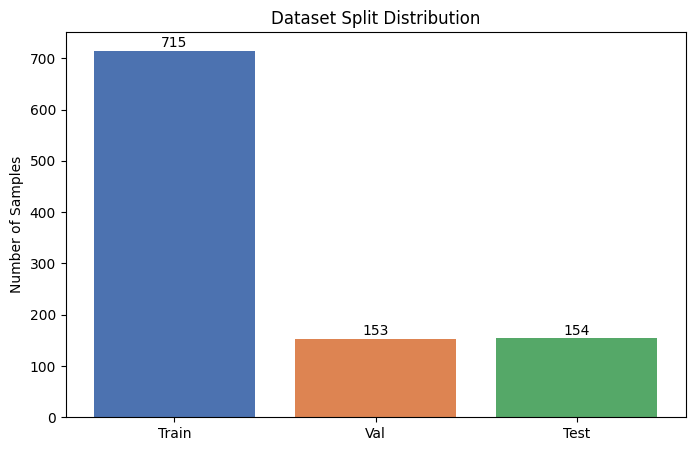

In [23]:
# Visualize Dataset Split Distribution
splits = ['Train', 'Val', 'Test']
counts = [len(train_ds), len(val_ds), len(test_ds)]

plt.figure(figsize=(8, 5))
plt.bar(splits, counts, color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Dataset Split Distribution')
plt.ylabel('Number of Samples')
for i, v in enumerate(counts):
    plt.text(i, v + max(counts)*0.01, str(v), ha='center')
plt.show()

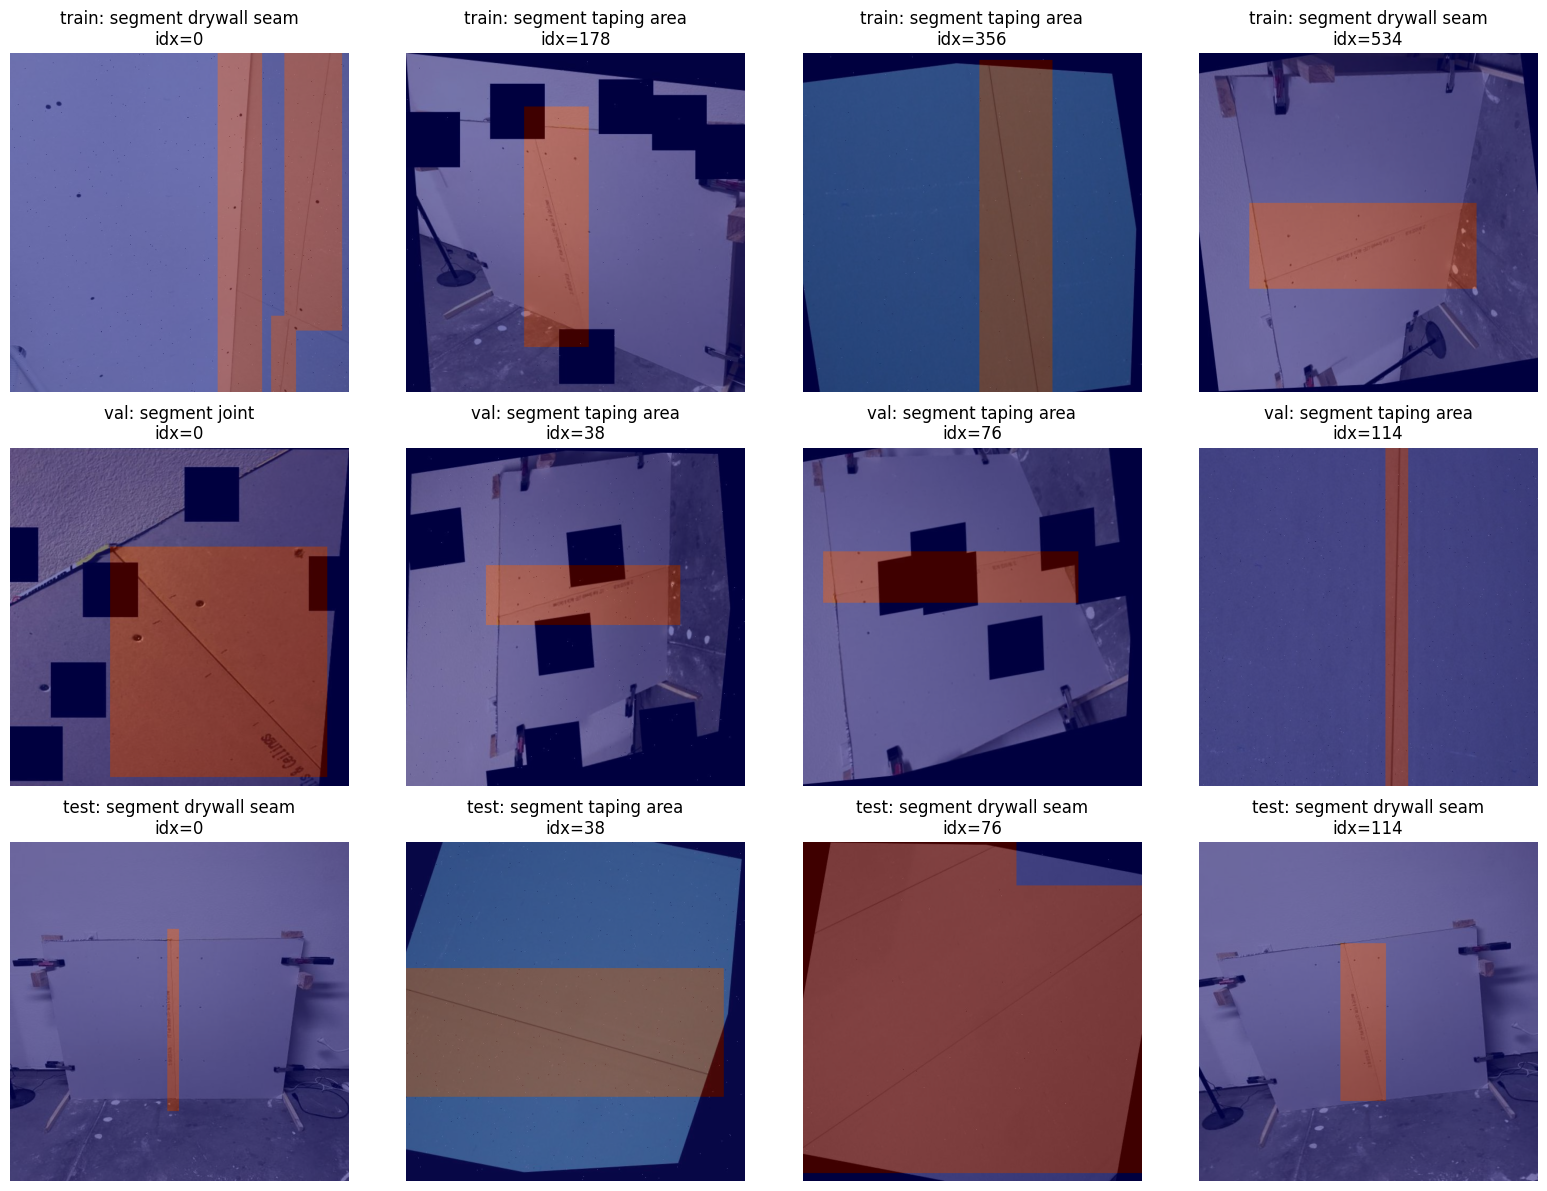

Saved: drywall_dataset_visualization.png


In [24]:
# Visualize dataset samples with prompts
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for row, split in enumerate(["train", "val", "test"]):
    ds = {"train": train_ds, "val": val_ds, "test": test_ds}[split]
    
    for col in range(4):
        idx = col * (len(ds) // 4)
        image, mask, prompt = ds[idx]
        
        axes[row, col].imshow(image.permute(1, 2, 0))
        axes[row, col].imshow(mask, alpha=0.5, cmap="jet")
        axes[row, col].set_title(f"{split}: {prompt}\nidx={idx}")
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig("drywall_dataset_visualization.png", dpi=150)
plt.show()

print("Saved: drywall_dataset_visualization.png")

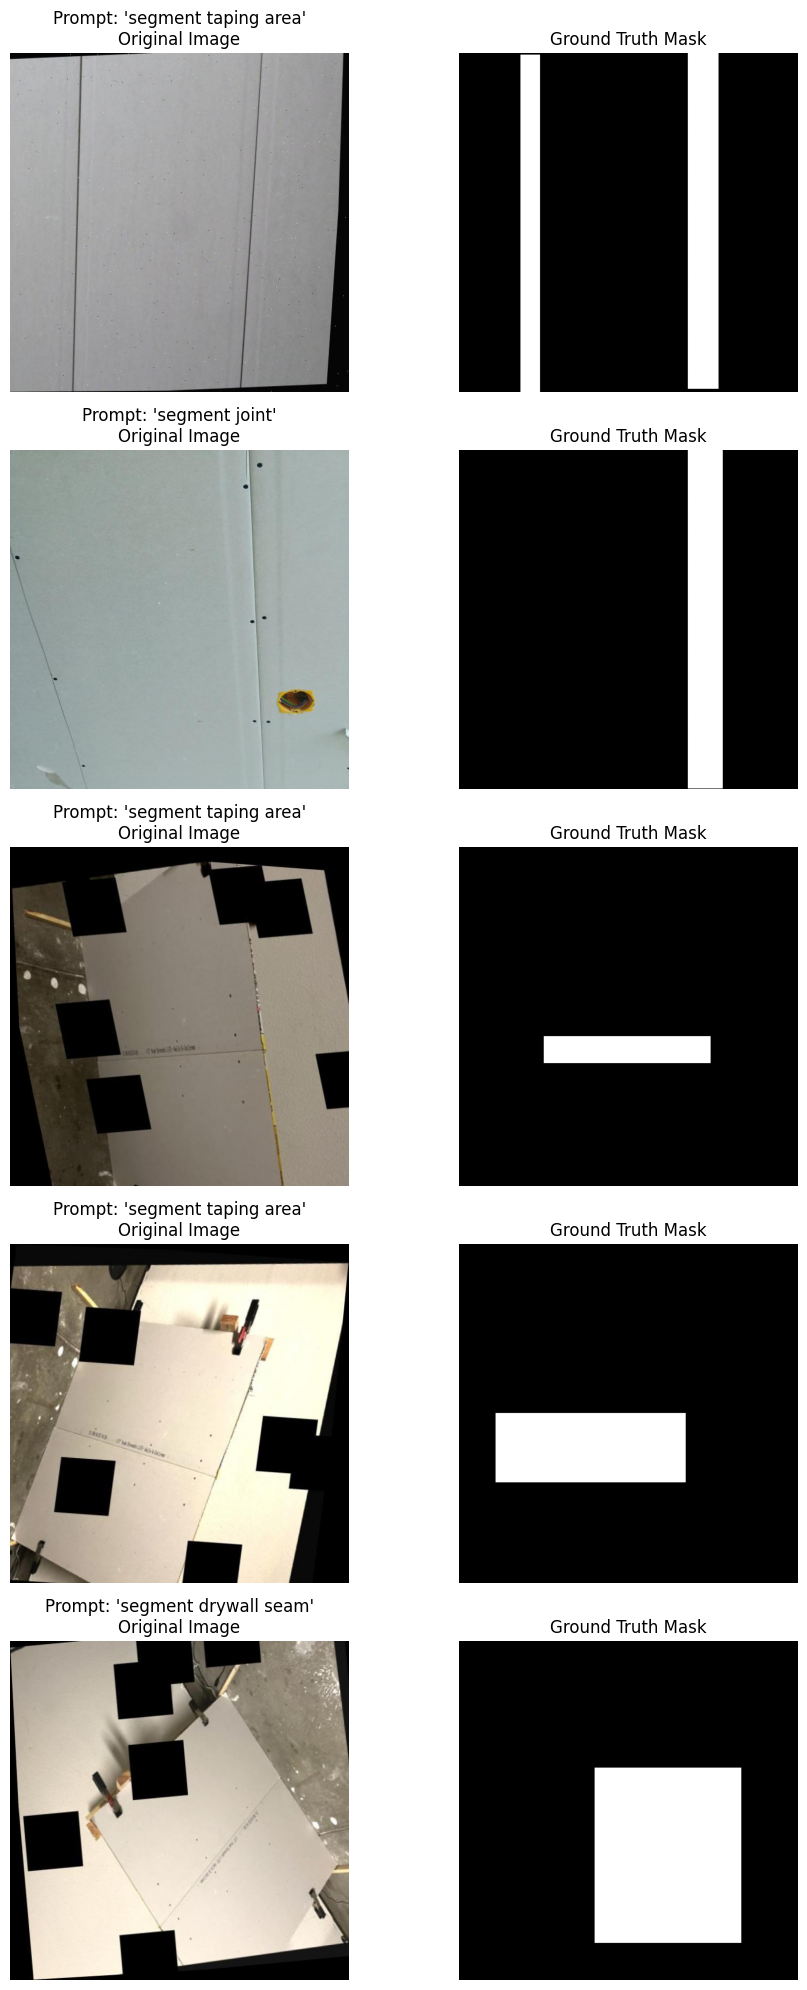

Saved: drywall_side_by_side_samples.png


In [25]:
# Visualize samples side-by-side (Original vs Ground Truth)
import random
num_samples = 5
fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))

for i in range(num_samples):
    idx = random.randint(0, len(train_ds) - 1)
    image, mask, prompt = train_ds[idx]
    
    # Original Image
    axes[i, 0].imshow(image.permute(1, 2, 0))
    axes[i, 0].set_title(f"Prompt: '{prompt}'\nOriginal Image")
    axes[i, 0].axis('off')
    
    # Ground Truth Mask
    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig("drywall_side_by_side_samples.png", dpi=150)
plt.show()

print("Saved: drywall_side_by_side_samples.png")

In [32]:
import numpy as np

def compute_metrics(pred, target, threshold=0.5):
    """Compute IoU (fg), mIoU (fg+bg), Foreground Precision, Recall, F1"""
    # Binarize
    pred = (pred > threshold).float()
    target = (target > threshold).float()
    
    # Foreground IoU
    fg_inter = (pred * target).sum()
    fg_union = pred.sum() + target.sum() - fg_inter
    fg_iou = (fg_inter + 1e-8) / (fg_union + 1e-8)
    
    # Background IoU
    bg_pred = 1 - pred
    bg_target = 1 - target
    bg_inter = (bg_pred * bg_target).sum()
    bg_union = bg_pred.sum() + bg_target.sum() - bg_inter
    bg_iou = (bg_inter + 1e-8) / (bg_union + 1e-8)
    
    # mIoU (fg + bg mean)
    miou = (fg_iou + bg_iou) / 2
    
    # Precision (mean across classes)
    fg_prec = (fg_inter + 1e-8) / (pred.sum() + 1e-8)
    bg_prec = (bg_inter + 1e-8) / (bg_pred.sum() + 1e-8)
    precision = fg_prec  # ONLY FOREGROUND
    
    # Recall (mean across classes)
    fg_rec = (fg_inter + 1e-8) / (target.sum() + 1e-8)
    bg_rec = (bg_inter + 1e-8) / (bg_target.sum() + 1e-8)
    recall = fg_rec  # ONLY FOREGROUND
    
    # F1 (mean across classes)
    fg_f1 = 2 * fg_prec * fg_rec / (fg_prec + fg_rec + 1e-8)
    bg_f1 = 2 * bg_prec * bg_rec / (bg_prec + bg_rec + 1e-8)
    f1 = fg_f1  # ONLY FOREGROUND
    
    return {
        "iou": fg_iou.item(),
        "miou": miou.item(),
        "precision": precision.item(),
        "recall": recall.item(),
        "f1": f1.item()
    }

def compute_batch_metrics(preds, targets, threshold=0.5):
    """Compute metrics for a batch"""
    metrics = {"iou": [], "miou": [], "precision": [], "recall": [], "f1": []}
    
    for pred, target in zip(preds, targets):
        m = compute_metrics(pred, target, threshold)
        for k, v in m.items():
            metrics[k].append(v) 
            
    return {
        "IoU": np.mean(metrics["iou"]),
        "mIoU": np.mean(metrics["miou"]),
        "Precision": np.mean(metrics["precision"]),
        "Recall": np.mean(metrics["recall"]),
        "F1": np.mean(metrics["f1"])
    }

In [27]:
import clip
from segment_anything import sam_model_registry

class FiLMGenerator(nn.Module):
    def __init__(self, text_dim=512, feat_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(text_dim, 256), nn.ReLU(inplace=True),
            nn.Linear(256, 256), nn.ReLU(inplace=True),
            nn.Linear(256, feat_dim * 2) 
        )
        nn.init.zeros_(self.mlp[-1].weight)
        nn.init.zeros_(self.mlp[-1].bias)
        with torch.no_grad(): self.mlp[-1].bias[:feat_dim] = 1.0

    def forward(self, text_emb):
        out = self.mlp(text_emb)
        return out[:, :256], out[:, 256:]

    def modulate(self, features, gamma, beta):
        return gamma[:, :, None, None] * features + beta[:, :, None, None]

class DilatedDecoder(nn.Module):
    def __init__(self, in_dim=256, out_dim=128):
        super().__init__()
        b_dim = in_dim // 4
        self.global_ctx = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(in_dim, b_dim, 1), nn.ReLU(inplace=True))
        self.d1 = nn.Sequential(nn.Conv2d(in_dim, b_dim, 3, padding=1, dilation=1, bias=False), nn.GroupNorm(8, b_dim), nn.ReLU(inplace=True))
        self.d3 = nn.Sequential(nn.Conv2d(in_dim, b_dim, 3, padding=3, dilation=3, bias=False), nn.GroupNorm(8, b_dim), nn.ReLU(inplace=True))
        self.d6 = nn.Sequential(nn.Conv2d(in_dim, b_dim, 3, padding=6, dilation=6, bias=False), nn.GroupNorm(8, b_dim), nn.ReLU(inplace=True))
        self.d12 = nn.Sequential(nn.Conv2d(in_dim, b_dim, 3, padding=12, dilation=12, bias=False), nn.GroupNorm(8, b_dim), nn.ReLU(inplace=True))
        self.project = nn.Sequential(nn.Conv2d(b_dim * 5, out_dim, 1), nn.GroupNorm(8, out_dim), nn.ReLU(inplace=True), nn.Dropout2d(0.1))

    def forward(self, x):
        ctx = self.global_ctx(x).expand(-1, -1, x.shape[2], x.shape[3])
        return self.project(torch.cat([ctx, self.d1(x), self.d3(x), self.d6(x), self.d12(x)], dim=1))

class EdgeAwareHead(nn.Module):
    def __init__(self, feat_dim=16):
        super().__init__()
        laplacian = torch.tensor([[0., 1., 0.], [1., -4., 1.], [0., 1., 0.]], dtype=torch.float32).unsqueeze(0).unsqueeze(0).repeat(1, 1, 1, 1)
        self.register_buffer("laplacian_kernel", laplacian)
        
        self.edge_encoder = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(inplace=True), nn.Conv2d(16, 16, 3, padding=1), nn.ReLU(inplace=True))
        self.channel_attn = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(feat_dim + 16, 16), nn.ReLU(inplace=True), nn.Linear(16, feat_dim), nn.Sigmoid())
        
        self.refine = nn.Sequential(
            nn.Conv2d(feat_dim + 16, feat_dim, 3, padding=1), nn.GroupNorm(4, feat_dim), nn.ReLU(inplace=True),
            nn.Conv2d(feat_dim, feat_dim // 2, 3, padding=1), nn.GroupNorm(4, feat_dim // 2), nn.ReLU(inplace=True)
        )
        self.head = nn.Conv2d(feat_dim // 2, 1, 1)

    def extract_edges(self, image):
        gray = 0.299 * image[:, 0:1] + 0.587 * image[:, 1:2] + 0.114 * image[:, 2:3]
        edges = F.conv2d(gray, self.laplacian_kernel, padding=1).abs()
        B = edges.shape[0]
        max_vals = edges.view(B, -1).max(dim=1)[0].view(B, 1, 1, 1).clamp(min=1e-6)
        return edges / max_vals

    def forward(self, feats, image):
        image_resized = F.interpolate(image, size=(feats.shape[2], feats.shape[3]), mode="bilinear", align_corners=False)
        edge_map = self.extract_edges(image_resized)
        edge_feats = self.edge_encoder(edge_map)
        
        attn = self.channel_attn(torch.cat([feats, edge_feats], dim=1))[:, :, None, None]
        gated = feats * attn
        
        refined = self.refine(torch.cat([gated, edge_feats], dim=1))
        return self.head(refined)

In [28]:
class AdvancedSAMFiLM(nn.Module):
    def __init__(self, image_size=640):
        super().__init__()
        self.image_size = image_size
        
        # SAM Encoder
        self.sam = sam_model_registry["vit_b"]()
        
        # Resize pos embeddings
        grid_size = image_size // 16
        old_pos = self.sam.image_encoder.pos_embed
        new_pos = F.interpolate(old_pos.permute(0, 3, 1, 2), size=(grid_size, grid_size), mode='bicubic', align_corners=False)
        self.sam.image_encoder.pos_embed = nn.Parameter(new_pos.permute(0, 2, 3, 1))
        for param in self.sam.image_encoder.parameters(): param.requires_grad = False
        
        # Advanced Modules
        self.film = FiLMGenerator(text_dim=512, feat_dim=256)
        self.dilated = DilatedDecoder(in_dim=256, out_dim=128)
        
        # Upsampler
        self.upsampler = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(),
        )
        self.edge_head = EdgeAwareHead(feat_dim=16)
        
    def forward(self, img, text_emb):
        with torch.no_grad(): img_features = self.sam.image_encoder(img)
        gamma, beta = self.film(text_emb)
        modulated = self.film.modulate(img_features, gamma, beta)
        
        decoded = self.dilated(modulated)
        upsampled = self.upsampler(decoded)
        logits = self.edge_head(upsampled, img)
        return logits.squeeze(1)

print("Loading CLIP and SAM models...")
clip_model, _ = clip.load("ViT-B/32", cfg.DEVICE)
clip_model = clip_model.float().eval()

# Load SAM checkpoint if exists, else create model without checkpoint
try:
    model = AdvancedSAMFiLM(image_size=cfg.IMAGE_SIZE).to(cfg.DEVICE)
    # Try to load checkpoint if available
    if os.path.exists("sam_vit_b_01ec64.pth"):
        state_dict = torch.load("sam_vit_b_01ec64.pth", map_location=cfg.DEVICE)
        model.sam.load_state_dict(state_dict)
        print("SAM weights loaded!")
except:
    print("Creating model without SAM weights...")
    model = AdvancedSAMFiLM(image_size=cfg.IMAGE_SIZE).to(cfg.DEVICE)

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.LEARNING_RATE)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Loading CLIP and SAM models...
Trainable parameters: 5,227,025


In [29]:
class SegmentationLoss(nn.Module):
    def __init__(self):
        super().__init__()
        lap = torch.tensor([[0., 1., 0.], [1., -4., 1.], [0., 1., 0.]], dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        self.register_buffer("lap_kernel", lap)

    def forward(self, logits, targets):
        if logits.dim() == 3: logits = logits.unsqueeze(1)
        if targets.dim() == 3: targets = targets.unsqueeze(1)
        
        # BCE with Positive Weighting
        pos_weight = torch.tensor([15.0], device=logits.device)
        l_bce = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=pos_weight)
        
        # DICE
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).flatten(1).sum(dim=1)
        union = probs.flatten(1).sum(dim=1) + targets.flatten(1).sum(dim=1)
        l_dice = (1.0 - (2.0 * intersection + 1e-5) / (union + 1e-5)).mean()
        
        # EDGE
        gt_edges = F.conv2d(targets, self.lap_kernel, padding=1).abs()
        gt_edges = (gt_edges > 0.1).float()
        
        edge_bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        l_edge = (edge_bce * (1.0 + 5.0 * gt_edges)).mean()
        
        return l_bce + 2.0 * l_dice + 0.2 * l_edge

criterion = SegmentationLoss().to(cfg.DEVICE)

In [30]:
print("Building text prompt cache...")
with torch.no_grad():
    text_cache = {}
    for prompt in cfg.PROMPTS:
        tokens = clip.tokenize(prompt).to(cfg.DEVICE)
        text_cache[prompt] = clip_model.encode_text(tokens)
    print(f"Cached {len(text_cache)} prompts")

def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    for images, masks, prompts in dataloader:
        images = images.to(cfg.DEVICE)
        masks = masks.to(cfg.DEVICE)
        
        text_emb = torch.stack([text_cache[p] for p in prompts]).squeeze(1).to(cfg.DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images, text_emb)
        
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        all_preds.append(outputs.detach())
        all_targets.append(masks)
    
    metrics = compute_batch_metrics(all_preds, all_targets)
    metrics["loss"] = total_loss / len(dataloader)
    return metrics

def validate(model, dataloader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for images, masks, prompts in dataloader:
            images = images.to(cfg.DEVICE)
            masks = masks.to(cfg.DEVICE)
            text_emb = torch.stack([text_cache[cfg.PROMPTS[0]]] * len(prompts)).squeeze(1).to(cfg.DEVICE)
            
            outputs = model(images, text_emb)
            loss = criterion(outputs, masks)
            
            total_loss += loss.item()
            all_preds.append(outputs)
            all_targets.append(masks)
    
    metrics = compute_batch_metrics(all_preds, all_targets)
    metrics["loss"] = total_loss / len(dataloader)
    return metrics

Building text prompt cache...
Cached 3 prompts


In [33]:
train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=4)

history = {
    "train_loss": [], "train_IoU": [], "train_mIoU": [],
    "val_loss": [], "val_IoU": [], "val_mIoU": []
}

print("Starting training...")
print(f"Epochs: {cfg.NUM_EPOCHS}")
print("-" * 80)

best_miou = 0
for epoch in range(cfg.NUM_EPOCHS):
    train_metrics = train_epoch(model, train_loader, optimizer, criterion)
    val_metrics = validate(model, val_loader, criterion)
    
    if val_metrics["mIoU"] > best_miou:
        best_miou = val_metrics["mIoU"]
        torch.save(model.state_dict(), "best_drywall_model.pth")
    
    print(f"Epoch {epoch+1:2d}/{cfg.NUM_EPOCHS}")
    print(f"  Train - Loss: {train_metrics['loss']:.4f}, IoU: {train_metrics['IoU']:.4f}, mIoU: {train_metrics['mIoU']:.4f}, " +
          f"Precision: {train_metrics['Precision']:.4f}, Recall: {train_metrics['Recall']:.4f}, " +
          f"F1: {train_metrics['F1']:.4f}")
    print(f"  Val   - Loss: {val_metrics['loss']:.4f}, IoU: {val_metrics['IoU']:.4f}, mIoU: {val_metrics['mIoU']:.4f}, " +
          f"Precision: {val_metrics['Precision']:.4f}, Recall: {val_metrics['Recall']:.4f}, " +
          f"F1: {val_metrics['F1']:.4f}")
    print("-" * 80)
    
    history["train_loss"].append(train_metrics["loss"])
    history["train_IoU"].append(train_metrics["IoU"])
    history["train_mIoU"].append(train_metrics["mIoU"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_IoU"].append(val_metrics["IoU"])
    history["val_mIoU"].append(val_metrics["mIoU"])
    
print(f"Training complete! Best mIoU: {best_miou:.4f}")

Starting training...
Epochs: 20
--------------------------------------------------------------------------------
Epoch  1/20
  Train - Loss: 2.7064, IoU: 0.3204, mIoU: 0.4825, Precision: 0.3343, Recall: 0.9045, F1: 0.4737
  Val   - Loss: 2.8610, IoU: 0.3201, mIoU: 0.4918, Precision: 0.3458, Recall: 0.8496, F1: 0.4712
--------------------------------------------------------------------------------
Epoch  2/20
  Train - Loss: 2.6666, IoU: 0.3314, mIoU: 0.4948, Precision: 0.3472, Recall: 0.9037, F1: 0.4849
  Val   - Loss: 2.8913, IoU: 0.3084, mIoU: 0.4703, Precision: 0.3318, Recall: 0.8583, F1: 0.4576
--------------------------------------------------------------------------------
Epoch  3/20
  Train - Loss: 2.6213, IoU: 0.3360, mIoU: 0.5021, Precision: 0.3504, Recall: 0.9070, F1: 0.4916
  Val   - Loss: 2.9223, IoU: 0.2988, mIoU: 0.4600, Precision: 0.3221, Recall: 0.8484, F1: 0.4461
--------------------------------------------------------------------------------
Epoch  4/20
  Train - Loss

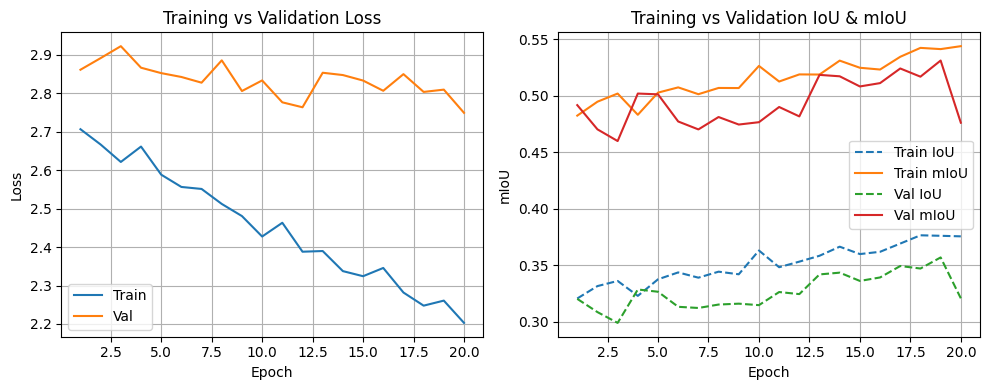

Saved: drywall_training_curves.png


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

epochs = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"], label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history["train_IoU"], label="Train IoU", linestyle="--")
axes[1].plot(epochs, history["train_mIoU"], label="Train mIoU")
axes[1].plot(epochs, history["val_IoU"], label="Val IoU", linestyle="--")
axes[1].plot(epochs, history["val_mIoU"], label="Val mIoU")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mIoU")
axes[1].set_title("Training vs Validation IoU & mIoU")
axes[1].legend()
axes[1].grid(True)


plt.tight_layout()
plt.savefig("drywall_training_curves.png", dpi=150)
plt.show()
print("Saved: drywall_training_curves.png")